In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r"C:\Users\Fazal\OneDrive\Desktop\Internship\Task-6\sales_data.csv")

# Show column names and first few rows
print(df.columns.tolist())
print(df.head())

['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group', 'Customer_Gender', 'Country', 'State', 'Product_Category', 'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Profit', 'Cost', 'Revenue']
         Date  Day     Month  Year  Customer_Age       Age_Group  \
0  26/11/2013   26  November  2013            19     Youth (<25)   
1  26/11/2015   26  November  2015            19     Youth (<25)   
2  23/03/2014   23     March  2014            49  Adults (35-64)   
3  23/03/2016   23     March  2016            49  Adults (35-64)   
4  15/05/2014   15       May  2014            47  Adults (35-64)   

  Customer_Gender    Country             State Product_Category Sub_Category  \
0               M     Canada  British Columbia      Accessories   Bike Racks   
1               M     Canada  British Columbia      Accessories   Bike Racks   
2               M  Australia   New South Wales      Accessories   Bike Racks   
3               M  Australia   New South Wales   

C:\Users\Fazal\AppData\Local\Temp\ipykernel_29276\3948980676.py:13: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(r"C:\Users\Fazal\OneDrive\Desktop\Internship\Task-6\sales_data.csv", parse_dates=['Date'])


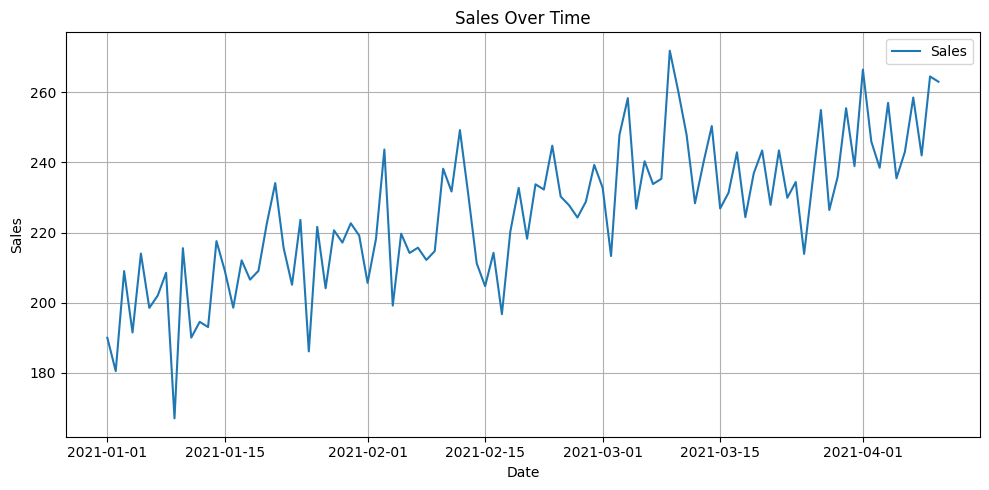

C:\Users\Fazal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Fazal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Fazal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Fazal\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Fazal


Forecasted Sales:

            Actual_Sales  Forecasted_Sales
Date                                      
2021-04-01    266.454545        238.434397
2021-04-02    245.959596        239.510111
2021-04-03    238.464646        238.630481
2021-04-04    256.969697        239.299964
2021-04-05    235.474747        238.795058
2021-04-06    242.979798        239.175381
2021-04-07    258.484848        238.888947
2021-04-08    241.989899        239.104665
2021-04-09    264.494949        238.942205
2021-04-10    263.000000        239.064556


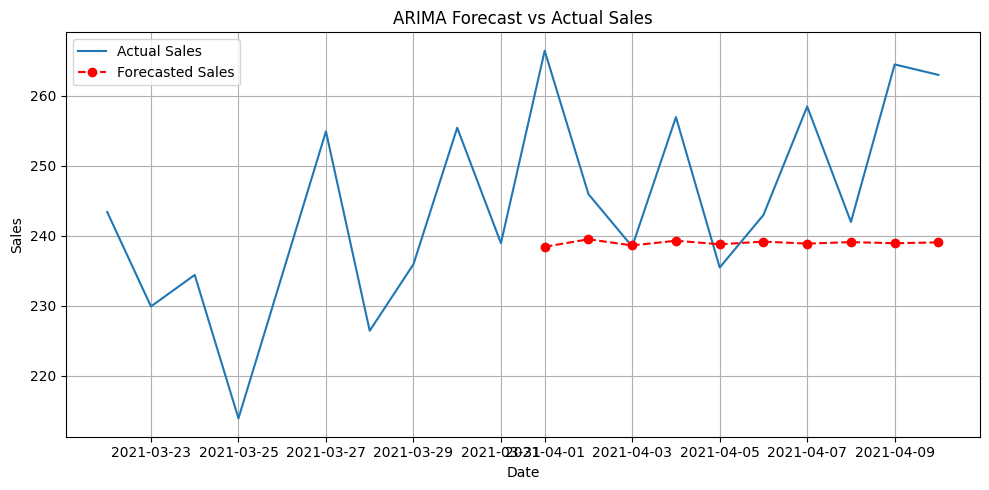


Model Evaluation:
RMSE: 16.68
MAPE: 5.06%


In [16]:
# Time Series Forecasting with ARIMA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()

#Load dataset
df = pd.read_csv(r"C:\Users\Fazal\OneDrive\Desktop\Internship\Task-6\sales_data.csv", parse_dates=['Date'])
dates = pd.date_range(start="2021-01-01", periods=100, freq='D')
sales = np.random.poisson(lam=200, size=100) + np.linspace(0, 50, 100)  # trend + randomness
df = pd.DataFrame({'Date': dates, 'Sales': sales})
df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)

#Trend Analysis Plot
plt.figure(figsize=(10, 5))
plt.plot(df['Sales'], label='Sales')
plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#ARIMA Forecasting
train = df['Sales'][:-10]
test = df['Sales'][-10:]

model = ARIMA(train, order=(2, 1, 2))
model_fit = model.fit()
forecast = model_fit.forecast(steps=10)

# Create Forecast DataFrame
forecast_dates = test.index
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Actual_Sales': test.values,
    'Forecasted_Sales': forecast.values
})
forecast_df.set_index('Date', inplace=True)
print("\nForecasted Sales:\n")
print(forecast_df)

#Forecast vs Actual Plot
plt.figure(figsize=(10, 5))
plt.plot(df.index[-20:], df['Sales'][-20:], label='Actual Sales')
plt.plot(forecast.index, forecast, label='Forecasted Sales', color='red', linestyle='--', marker='o')
plt.title('ARIMA Forecast vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Evaluation
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)

print(f"\nModel Evaluation:")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape * 100:.2f}%")

In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r"C:\Users\Fazal\OneDrive\Desktop\Internship\Task-6\heart_disease.csv")

# Show column names and first few rows
print(df.columns.tolist())
print(df.head())

['age', 'Gender', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
   age  Gender  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0   52       1   0       125   212    0        1      168      0      1.0   
1   53       1   0       140   203    1        0      155      1      3.1   
2   70       1   0       145   174    0        1      125      1      2.6   
3   61       1   0       148   203    0        1      161      0      0.0   
4   62       0   0       138   294    1        1      106      0      1.9   

   slope  ca  thal  target  
0      2   2     3       0  
1      0   0     3       0  
2      0   0     3       0  
3      2   1     3       0  
4      1   3     2       0  



Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.64      0.67       159
           1       0.65      0.70      0.68       149

    accuracy                           0.67       308
   macro avg       0.67      0.67      0.67       308
weighted avg       0.67      0.67      0.67       308



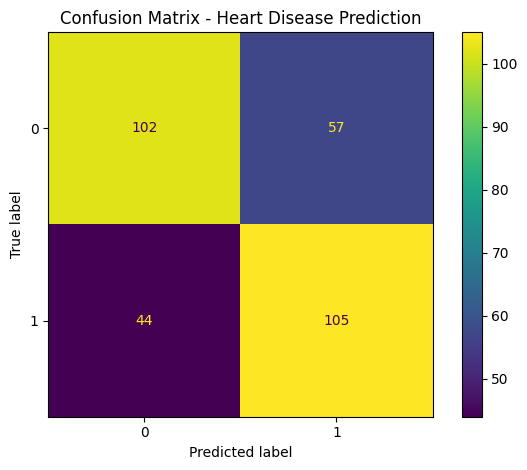

In [11]:
# Heart Disease Prediction using Logistic Regression
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load the dataset
df = pd.read_csv(r"C:\Users\Fazal\OneDrive\Desktop\Internship\Task-6\heart_disease.csv")

# Preprocessing: encode Gender if needed
if df['Gender'].dtype == object:
    df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Define features and target based on actual column names
features = ['age', 'Gender', 'chol', 'trestbps']
X = df[features]
y = df['target']  # 'target' is the column representing heart disease presence

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Model training
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction and evaluation
y_pred = model.predict(X_test)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title('Confusion Matrix - Heart Disease Prediction')
plt.tight_layout()
plt.show()